# VARMA Implementation Testing Notebook

This notebook tests the VARMA-OLS implementation step by step:
- Start with a single channel
- Expand to multiple channels
- Test per-channel z-scoring
- Test predictions and forecasts
- Visualize results

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Create Synthetic Data Generator

Generate simple time series data for testing

In [2]:
def generate_synthetic_data(n_trials=3, n_samples_per_trial=500, n_channels=1, seed=42):
    """
    Generate synthetic time series data using sinusoids with variable amplitude.

    Parameters:
    -----------
    n_trials : int
        Number of trials
    n_samples_per_trial : int
        Number of time samples per trial
    n_channels : int
        Number of channels (start with 1, can expand)
    seed : int
        Random seed for reproducibility

    Returns:
    --------
    Y_list : list of arrays
        List of (n_samples, n_channels) arrays, one per trial
    """
    np.random.seed(seed)
    Y_list = []

    for trial in range(n_trials):
        y = np.zeros((n_samples_per_trial, n_channels))
        t = np.arange(n_samples_per_trial)

        for ch in range(n_channels):
            # Different frequency per channel
            base_freq = 0.05 + 0.02 * ch  # Different base frequency per channel
            freq = base_freq + np.random.randn() * 0.01  # Slight variation per trial

            # Variable amplitude - use multiple waves to create complex amplitude modulation
            base_amp = 1.0 + 0.5 * ch  # Base amplitude increases per channel

            # Multiple amplitude modulation frequencies for complex envelope
            amp_freq1 = 0.01 + 0.005 * ch  # Slow modulation
            amp_freq2 = 0.03 + 0.01 * ch  # Medium modulation
            amp_freq3 = 0.08 + 0.02 * ch  # Faster modulation

            # Combine multiple sinusoids for complex amplitude envelope
            amp_mod1 = 0.4 * np.sin(2 * np.pi * amp_freq1 * t)
            amp_mod2 = 0.3 * np.sin(
                2 * np.pi * amp_freq2 * t + np.pi / 4
            )  # Phase offset
            amp_mod3 = 0.2 * np.sin(
                2 * np.pi * amp_freq3 * t + np.pi / 2
            )  # Different phase

            # Combine all amplitude modulations
            amplitude = base_amp * (1.0 + amp_mod1 + amp_mod2 + amp_mod3)

            # Ensure amplitude stays positive
            amplitude = np.maximum(amplitude, 0.1 * base_amp)

            # Generate sinusoid with variable amplitude
            phase = np.random.rand() * 2 * np.pi  # Random phase per trial/channel
            y[:, ch] = amplitude * np.sin(2 * np.pi * freq * t + phase)

            # Add a slow trend (optional, can be removed)
            trend = 0.0005 * t * (1 + ch * 0.3)
            y[:, ch] += trend

        Y_list.append(y)

    return Y_list


# Test with single channel
Y_single = generate_synthetic_data(n_trials=3, n_samples_per_trial=500, n_channels=1)
print(f"Generated {len(Y_single)} trials")
print(f"Each trial shape: {Y_single[0].shape}")
print(f"Data range: [{Y_single[0].min():.4f}, {Y_single[0].max():.4f}]")

Generated 3 trials
Each trial shape: (500, 1)
Data range: [-1.7567, 1.9512]


## 3. Visualize Synthetic Data

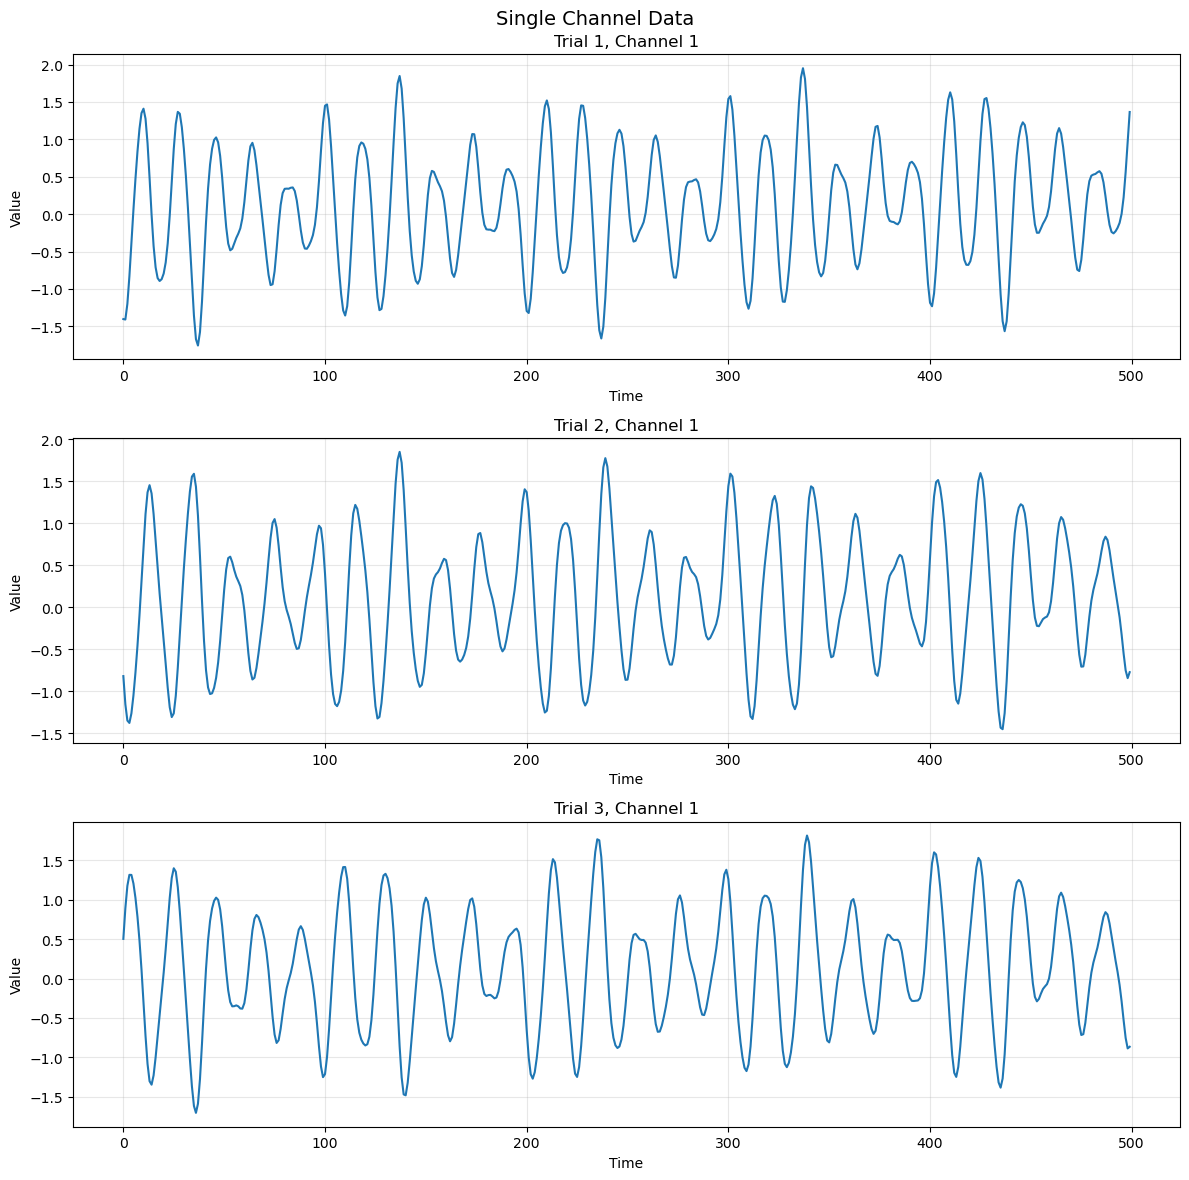

In [3]:
def plot_trials(Y_list, title="Synthetic Data", max_trials=3):
    """Plot the first few trials"""
    n_trials = min(len(Y_list), max_trials)
    n_channels = Y_list[0].shape[1]

    fig, axes = plt.subplots(n_trials, n_channels, figsize=(12, 4 * n_trials))
    if n_trials == 1:
        axes = axes.reshape(1, -1)
    if n_channels == 1:
        axes = axes.reshape(-1, 1)

    for trial_idx in range(n_trials):
        for ch_idx in range(n_channels):
            ax = axes[trial_idx, ch_idx]
            ax.plot(Y_list[trial_idx][:, ch_idx])
            ax.set_title(f"Trial {trial_idx+1}, Channel {ch_idx+1}")
            ax.set_xlabel("Time")
            ax.set_ylabel("Value")
            ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_trials(Y_single, title="Single Channel Data")

In [4]:
# Visualize predictions
def plot_predictions(Y_true, Y_pred, trial_idx=0, max_samples=200):
    """Plot true vs predicted for a single trial"""
    n_channels = Y_true[trial_idx].shape[1]

    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 4 * n_channels))
    if n_channels == 1:
        axes = [axes]

    for ch_idx in range(n_channels):
        ax = axes[ch_idx]
        y_true = Y_true[trial_idx][:max_samples, ch_idx]
        y_pred = Y_pred[trial_idx][:max_samples, ch_idx]

        ax.plot(y_true, label="True", alpha=0.7)
        ax.plot(y_pred, label="Predicted", alpha=0.7)
        ax.set_title(f"Channel {ch_idx+1} - Predictions")
        ax.set_xlabel("Time")
        ax.set_ylabel("Value")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
# Visualize forecasts
def plot_forecasts(Y_true, Y_forecast, Y_past, trial_idx=0, history_len=100):
    """Plot history, true future, and forecast"""
    n_channels = Y_true[trial_idx].shape[1]

    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 4 * n_channels))
    if n_channels == 1:
        axes = [axes]

    for ch_idx in range(n_channels):
        ax = axes[ch_idx]

        # History
        history = Y_past[:, ch_idx]
        t_history = np.arange(len(history))
        ax.plot(t_history, history, "b-", label="History", alpha=0.7)

        # True future
        true_future = Y_true[trial_idx][
            history_len : history_len + len(Y_forecast), ch_idx
        ]
        t_future = np.arange(history_len, history_len + len(true_future))
        ax.plot(t_future, true_future, "g-", label="True Future", alpha=0.7)

        # Forecast
        forecast = Y_forecast[:, ch_idx]
        ax.plot(t_future, forecast, "r--", label="Forecast", alpha=0.7)

        # Vertical line at forecast start
        ax.axvline(
            x=history_len, color="k", linestyle=":", alpha=0.5, label="Forecast Start"
        )

        ax.set_title(f"Channel {ch_idx+1} - Forecasts")
        ax.set_xlabel("Time")
        ax.set_ylabel("Value")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7. Test with Neural (Y) and Behavioral (Z) Channels

Test the case where we have both neural input (Y) and behavioral output (Z) channels with very different scales

In [6]:
# Generate Y (neural) and Z (behavioral) with very different scales
# Y: smaller scale (neural features)
# Z: larger scale (behavioral like position, velocity, acceleration, jerk)

Y_neural = generate_synthetic_data(
    n_trials=3, n_samples_per_trial=500, n_channels=2, seed=42
)
# Scale Y to be smaller (like neural features)
for y in Y_neural:
    y *= 0.1

Z_behavioral = generate_synthetic_data(
    n_trials=3, n_samples_per_trial=500, n_channels=3, seed=123
)
# Scale Z to have very different scales (like behavioral features)
# Channel 0: position (moderate scale)
# Channel 1: velocity (larger scale)
# Channel 2: acceleration/jerk (very large scale)
for i, z in enumerate(Z_behavioral):
    z[:, 0] *= 10  # position
    z[:, 1] *= 100  # velocity
    z[:, 2] *= 1000  # acceleration/jerk

print("Generated Y (neural) and Z (behavioral) channels:")
print(f"\nY (neural) - {Y_neural[0].shape[1]} channels:")
for ch in range(Y_neural[0].shape[1]):
    all_data = np.concatenate([y[:, ch] for y in Y_neural])
    print(
        f"  Channel {ch+1}: mean={all_data.mean():.4f}, std={all_data.std():.4f}, range=[{all_data.min():.4f}, {all_data.max():.4f}]"
    )

Generated Y (neural) and Z (behavioral) channels:

Y (neural) - 2 channels:
  Channel 1: mean=0.0125, std=0.0764, range=[-0.1757, 0.1951]
  Channel 2: mean=0.0163, std=0.1154, range=[-0.2548, 0.3083]


In [7]:
print(f"\nZ (behavioral) - {Z_behavioral[0].shape[1]} channels:")
for ch in range(Z_behavioral[0].shape[1]):
    all_data = np.concatenate([z[:, ch] for z in Z_behavioral])
    print(
        f"  Channel {ch+1}: mean={all_data.mean():.4f}, std={all_data.std():.4f}, range=[{all_data.min():.4f}, {all_data.max():.4f}]"
    )


Z (behavioral) - 3 channels:
  Channel 1: mean=1.1450, std=7.5638, range=[-17.0299, 19.6806]
  Channel 2: mean=15.5970, std=115.6951, range=[-243.9885, 304.3850]
  Channel 3: mean=199.8598, std=1519.0950, range=[-3214.3669, 3676.6696]


## 8. VARMA Implementation

Test the VARMA robust VARMA implementation directly


In [8]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import pandas as pd
from typing import Optional


def calc_long_AR_residuals(df: pd.DataFrame, long_ar_lags: int) -> pd.DataFrame:
    """
    Compute residuals from a 'long' AR (or VAR) model.
    Uses AutoReg for 1 channel, VAR otherwise.
    """
    if df.shape[1] == 1:
        # Single channel: fallback to univariate AR
        from statsmodels.tsa.ar_model import AutoReg

        data_1d = df.iloc[:, 0].values
        ar_results = AutoReg(data_1d, lags=long_ar_lags).fit()
        resid = (data_1d[long_ar_lags:] - ar_results.fittedvalues).reshape(-1, 1)
        return pd.DataFrame(resid, index=df.index[long_ar_lags:], columns=df.columns)
    # Multi-channel
    return VAR(df).fit(maxlags=long_ar_lags).resid


def build_companion_matrix(beta_ols: np.ndarray, p: int, k: int) -> np.ndarray:
    """
    Build VAR(p)'s companion matrix from OLS β coefficients.
    """
    C = np.zeros((p * k, p * k))
    for i in range(p):
        # Each VAR lag block is k x k, stored transposed in OLS beta
        A_i = beta_ols[1 + i * k : 1 + (i + 1) * k, :].T
        C[:k, i * k : (i + 1) * k] = A_i
    if p > 1:
        C[k:, :-k] = np.eye((p - 1) * k)
    return C


def zscore_and_track_stats(
    arr: np.ndarray, offset: int, apply: bool, means: dict, stds: dict
):
    """
    Z-score arr columns if apply==True. Side-effect: stores per-channel means/stds.
    Returns normalized array.
    """
    out = np.zeros_like(arr)
    for ch in range(arr.shape[1]):
        m, s = arr[:, ch].mean(), arr[:, ch].std()
        if s < 1e-10:
            s = 1.0
        key = offset + ch
        means[key] = m
        stds[key] = s
        out[:, ch] = (arr[:, ch] - m) / s if apply else arr[:, ch]
    return out


def fit_regularized_robust_varma(
    Y: np.ndarray,
    Z: Optional[np.ndarray] = None,
    p: int = 20,
    q: int = 1,
    long_ar_lags: int = 20,
    target_pole_radius: float = 0.999,
    apply_zscoring: bool = True,
) -> tuple:
    """
    Robustly estimate a VARMA(p,q) via Hannan-Rissanen + pole constraint:
     - Y: neural, Z: behavioral features.
    Returns β, proxy residuals, poles, per-channel (mean, std), and sizes.
    """
    if Z is None:
        Z = Y.copy()

    nY, nZ = Y.shape[1], Z.shape[1]
    k_total = nY + nZ
    means, stds = {}, {}
    Yz = zscore_and_track_stats(
        Y, offset=0, apply=apply_zscoring, means=means, stds=stds
    )
    Zz = zscore_and_track_stats(
        Z, offset=nY, apply=apply_zscoring, means=means, stds=stds
    )
    df = pd.DataFrame(np.hstack([Yz, Zz]))
    k = df.shape[1]

    # Step 1/2: Compute proxy residuals for MA
    resid_proxy = calc_long_AR_residuals(df, long_ar_lags)
    effective_data = df.iloc[long_ar_lags:]

    # Build OLS design: stack AR and MA lags
    target = effective_data.iloc[max(p, q) :]
    X = []
    for lag in range(1, p + 1):
        X.append(effective_data.shift(lag).iloc[max(p, q) :].values)
    for lag in range(1, q + 1):
        X.append(resid_proxy.shift(lag).iloc[max(p, q) :].values)
    Xmat = sm.add_constant(np.hstack(X))

    # Step 3: β via OLS
    beta_ols = np.linalg.lstsq(Xmat, target, rcond=None)[0]

    # Step 4: Root constraint (pole radius)
    poles = {}
    if p > 0:
        companion = build_companion_matrix(beta_ols, p, k)
        orig_eigs = np.linalg.eigvals(companion)
        poles["original"] = orig_eigs
        maxpole = np.max(np.abs(orig_eigs))
        if maxpole > 0:
            gamma = target_pole_radius / maxpole
            for i in range(p):
                beta_ols[1 + i * k : 1 + (i + 1) * k, :] *= gamma ** (i + 1)
        reg_eigs = np.linalg.eigvals(build_companion_matrix(beta_ols, p, k))
        poles["regularized"] = reg_eigs

    return beta_ols, resid_proxy, poles, means, stds, nY, nZ


def forecast_varma_ols(beta_ols, history_data, history_resid, n_steps, p, q):
    """
    Forecast recursively using OLS β for VARMA, AR/MA lags, and history.
    """
    n_vars = history_data.shape[1]
    # Buffers for AR and MA context windows
    y_hist = list(history_data[-p:])
    e_hist = list(history_resid[-q:]) if q > 0 else []
    forecasts = []

    for _ in range(n_steps):
        # Build regressor: [const, AR lags ..., MA lags ...]
        reg = [1.0]
        for lag in range(1, p + 1):
            reg.extend(y_hist[-lag])
        for lag in range(1, q + 1):
            reg.extend(e_hist[-lag] if len(e_hist) >= lag else np.zeros(n_vars))
        y_next = np.array(reg) @ beta_ols
        forecasts.append(y_next)
        y_hist.append(y_next)
        e_hist.append(np.zeros(n_vars))  # Assume future error = 0

    return np.array(forecasts)

### Test VARMA Implementation with Single Channel

In [9]:
# Test VARMA implementation with single channel data
# Concatenate all trials for training
Y_concat_single = np.concatenate(Y_single, axis=0)
Z_concat_single = Y_concat_single.copy()  # Use Y as Z (replica)
print(f"Training data shape - Y: {Y_concat_single.shape}, Z: {Z_concat_single.shape}")

# Fit VARMA using VARMA method
p_super = 5
q_super = 1
long_ar_lags_super = 10
target_pole_radius = 0.999

print(f"\nFitting VARMA(p={p_super}, q={q_super}) using VARMA method...")
(
    beta_ols_super,
    resid_proxy_super,
    poles_super,
    channel_means_super,
    channel_stds_super,
    n_Y_super,
    n_Z_super,
) = fit_regularized_robust_varma(
    Y_concat_single,
    Z=Z_concat_single,
    p=p_super,
    q=q_super,
    long_ar_lags=long_ar_lags_super,
    target_pole_radius=target_pole_radius,
    apply_zscoring=True,
)

print(f"Beta shape: {beta_ols_super.shape}")
print(f"Residual proxy shape: {resid_proxy_super.shape}")
print(f"n_channels_Y: {n_Y_super}, n_channels_Z: {n_Z_super}")
print(f"\nPole information:")
print(f"  Original max pole: {np.max(np.abs(poles_super['original'])):.6f}")
print(f"  Regularized max pole: {np.max(np.abs(poles_super['regularized'])):.6f}")
print(f"  Target pole radius: {target_pole_radius}")
print(f"\nPer-channel normalization:")
for ch_idx in range(n_Y_super + n_Z_super):
    print(
        f"  Channel {ch_idx+1}: mean={channel_means_super[ch_idx]:.4f}, std={channel_stds_super[ch_idx]:.4f}"
    )

Training data shape - Y: (1500, 1), Z: (1500, 1)

Fitting VARMA(p=5, q=1) using VARMA method...
Beta shape: (13, 2)
Residual proxy shape: (1490, 2)
n_channels_Y: 1, n_channels_Z: 1

Pole information:
  Original max pole: 0.976914
  Regularized max pole: 0.999000
  Target pole radius: 0.999

Per-channel normalization:
  Channel 1: mean=0.1199, std=0.7654
  Channel 2: mean=0.1199, std=0.7654


In [10]:
# Test forecasts with VARMA method
trial_idx = 0
Y_past_super = Y_single[trial_idx][:100]  # Use first 100 samples as history
Z_past_super = Y_past_super.copy()  # Use Y as Z (replica)
m_super = 50  # Forecast 50 steps ahead

# Apply per-channel z-scoring to history
Y_past_zscored = np.zeros_like(Y_past_super)
for ch_idx in range(n_Y_super):
    mean_ch = channel_means_super[ch_idx]
    std_ch = channel_stds_super[ch_idx]
    Y_past_zscored[:, ch_idx] = (Y_past_super[:, ch_idx] - mean_ch) / std_ch

Z_past_zscored = np.zeros_like(Z_past_super)
for ch_idx in range(n_Z_super):
    global_ch_idx = n_Y_super + ch_idx
    mean_ch = channel_means_super[global_ch_idx]
    std_ch = channel_stds_super[global_ch_idx]
    Z_past_zscored[:, ch_idx] = (Z_past_super[:, ch_idx] - mean_ch) / std_ch

# Concatenate for residual computation
data_past = np.concatenate([Y_past_zscored, Z_past_zscored], axis=1)
data_past_df = pd.DataFrame(data_past)

# Get residuals for the history
if len(data_past) >= long_ar_lags_super:
    resid_past = calc_long_AR_residuals(data_past_df, long_ar_lags_super)
    history_resid_super = (
        resid_past.values[-q_super:]
        if len(resid_past) >= q_super
        else np.zeros((q_super, data_past.shape[1]))
    )
else:
    history_resid_super = np.zeros((q_super, data_past.shape[1]))

print(f"History data shape: {data_past.shape}")
print(f"History residual shape: {history_resid_super.shape}")

# Forecast using VARMA method (in z-scored space)
history_data_zscored = data_past[-p_super:]  # Last p samples
Yf_zscored = forecast_varma_ols(
    beta_ols_super,
    history_data=history_data_zscored,
    history_resid=history_resid_super,
    n_steps=m_super,
    p=p_super,
    q=q_super,
)

# Un-scale forecasts per-channel
Yf_super = np.zeros_like(Yf_zscored[:, :n_Y_super])
for ch_idx in range(n_Y_super):
    mean_ch = channel_means_super[ch_idx]
    std_ch = channel_stds_super[ch_idx]
    Yf_super[:, ch_idx] = Yf_zscored[:, ch_idx] * std_ch + mean_ch

print(f"Forecast shape: {Yf_super.shape}")
print(f"Forecast range: [{Yf_super.min():.4f}, {Yf_super.max():.4f}]")
print(f"Forecast std: {Yf_super.std():.4f}")

History data shape: (100, 2)
History residual shape: (1, 2)
Forecast shape: (50, 1)
Forecast range: [-1.3959, 1.6582]
Forecast std: 1.0709


### Test VARMA Predictions (One-Step-Ahead)

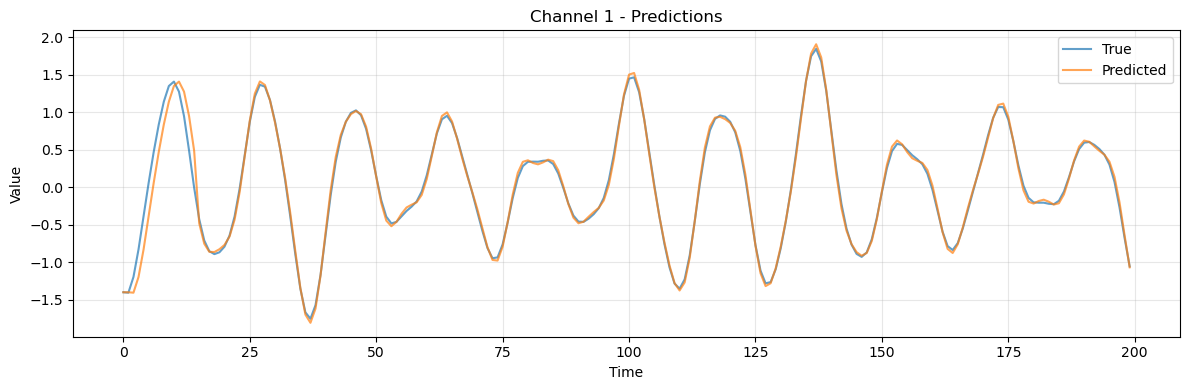

In [11]:
# Test one-step-ahead predictions with
def predict_varma_ols(beta_ols, data, resid_proxy, p, q, long_ar_lags):
    """
    Compute one-step-ahead predictions using VARMA parameters.
    Similar to forecast but for all time steps in the data.
    """
    df = pd.DataFrame(data)
    effective_data = df.iloc[long_ar_lags:]
    offset = max(p, q)

    # Build design matrix for predictions
    X_list = []
    for i in range(1, p + 1):
        X_list.append(effective_data.shift(i).iloc[offset:].values)
    for i in range(1, q + 1):
        X_list.append(resid_proxy.shift(i).iloc[offset:].values)

    X_matrix = np.concatenate(X_list, axis=1)
    X_matrix = sm.add_constant(X_matrix)

    # Predictions
    predictions_zscored = X_matrix @ beta_ols

    # Create full-length predictions array (pad with zeros/previous values for initial period)
    full_predictions = np.zeros_like(data)
    full_predictions[long_ar_lags + offset :] = predictions_zscored

    # For initial period, use previous observation
    if long_ar_lags + offset > 0:
        full_predictions[0] = data[0]
        for i in range(1, long_ar_lags + offset):
            full_predictions[i] = data[i - 1]

    return full_predictions


# Get predictions for single channel
# Concatenate Y and Z for prediction
Y_test_single = Y_single[0]  # Use first trial for testing
Z_test_single = Y_test_single.copy()

# Apply z-scoring
Y_test_zscored = np.zeros_like(Y_test_single)
for ch_idx in range(n_Y_super):
    mean_ch = channel_means_super[ch_idx]
    std_ch = channel_stds_super[ch_idx]
    Y_test_zscored[:, ch_idx] = (Y_test_single[:, ch_idx] - mean_ch) / std_ch

Z_test_zscored = np.zeros_like(Z_test_single)
for ch_idx in range(n_Z_super):
    global_ch_idx = n_Y_super + ch_idx
    mean_ch = channel_means_super[global_ch_idx]
    std_ch = channel_stds_super[global_ch_idx]
    Z_test_zscored[:, ch_idx] = (Z_test_single[:, ch_idx] - mean_ch) / std_ch

data_test = np.concatenate([Y_test_zscored, Z_test_zscored], axis=1)
data_test_df = pd.DataFrame(data_test)

# Compute residuals for this trial
resid_test = calc_long_AR_residuals(data_test_df, long_ar_lags_super)

# Get predictions
Yp_zscored_super = predict_varma_ols(
    beta_ols_super, data_test, resid_test, p_super, q_super, long_ar_lags_super
)

# Un-scale predictions
Yp_super = np.zeros_like(Yp_zscored_super[:, :n_Y_super])
for ch_idx in range(n_Y_super):
    mean_ch = channel_means_super[ch_idx]
    std_ch = channel_stds_super[ch_idx]
    Yp_super[:, ch_idx] = Yp_zscored_super[:, ch_idx] * std_ch + mean_ch

# Visualize predictions
plot_predictions([Y_test_single], [Yp_super], trial_idx=0)

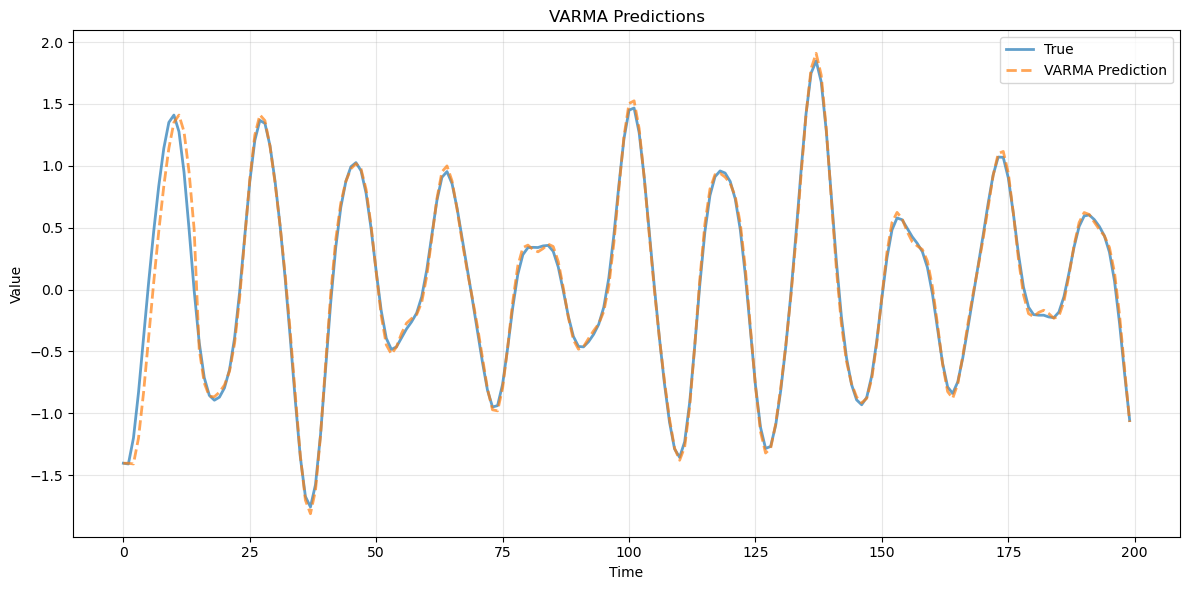

In [12]:
# Visualize VARMA predictions
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

y_true = Y_test_single[:200, 0]
y_pred_super = Yp_super[:200, 0]

ax.plot(y_true, label="True", alpha=0.7, linewidth=2)
ax.plot(y_pred_super, label=f"VARMA Prediction", alpha=0.7, linewidth=2, linestyle="--")
ax.set_title("VARMA Predictions")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

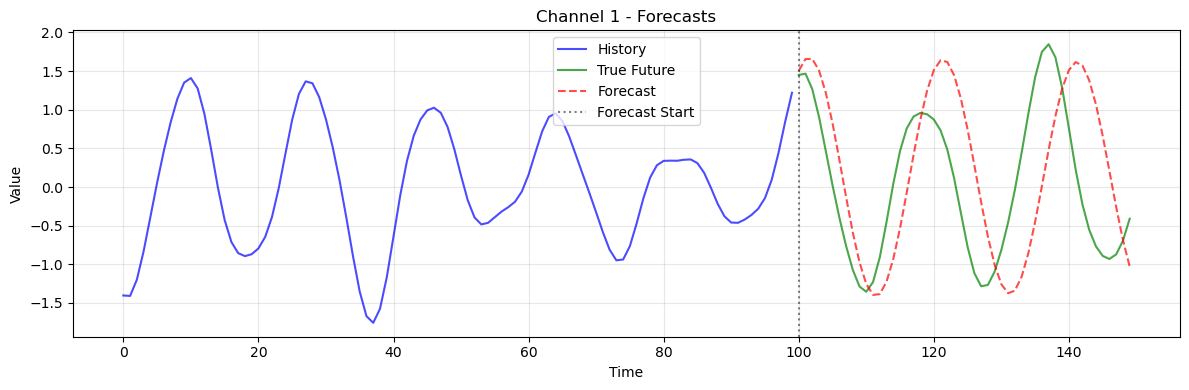

In [13]:
# Visualize VARMA forecasts
plot_forecasts(Y_single, Yf_super, Y_past_super, trial_idx=0, history_len=100)

### Test VARMA Predictions with Multi-Channel Data

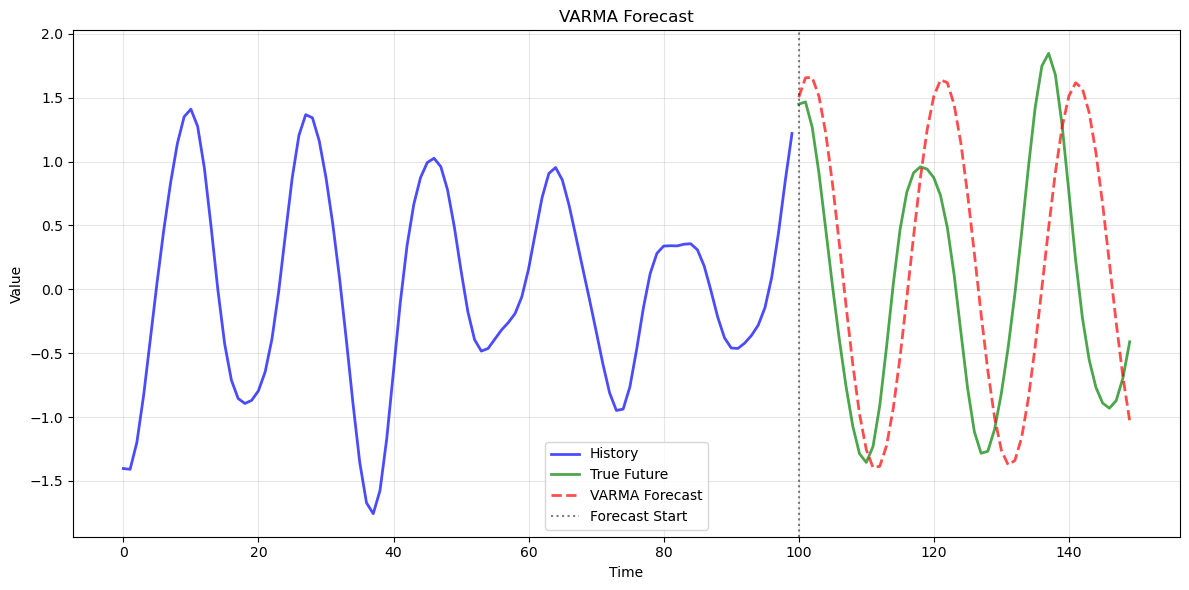

In [14]:
# Visualize VARMA forecasts
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

history = Y_past_super[:, 0]
t_history = np.arange(len(history))
ax.plot(t_history, history, "b-", label="History", alpha=0.7, linewidth=2)

true_future = Y_single[0][100 : 100 + len(Yf_super), 0]
t_future = np.arange(100, 100 + len(true_future))
ax.plot(t_future, true_future, "g-", label="True Future", alpha=0.7, linewidth=2)

forecast_super = Yf_super[:, 0]
ax.plot(t_future, forecast_super, "r--", label="VARMA Forecast", alpha=0.7, linewidth=2)

ax.axvline(x=100, color="k", linestyle=":", alpha=0.5, label="Forecast Start")
ax.set_title("VARMA Forecast")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Generate multi-channel data for testing
Y_multi = generate_synthetic_data(
    n_trials=3, n_samples_per_trial=500, n_channels=4, seed=42
)
print(f"Generated {len(Y_multi)} trials of multi-channel data")
print(f"Each trial shape: {Y_multi[0].shape}")
print(f"Data range: [{Y_multi[0].min():.4f}, {Y_multi[0].max():.4f}]")
print(f"\nPer-channel statistics:")
for ch in range(Y_multi[0].shape[1]):
    all_data = np.concatenate([y[:, ch] for y in Y_multi])
    print(
        f"  Channel {ch+1}: mean={all_data.mean():.4f}, std={all_data.std():.4f}, range=[{all_data.min():.4f}, {all_data.max():.4f}]"
    )

Generated 3 trials of multi-channel data
Each trial shape: (500, 4)
Data range: [-4.2081, 4.6508]

Per-channel statistics:
  Channel 1: mean=0.1236, std=0.7623, range=[-1.7567, 1.9512]
  Channel 2: mean=0.1581, std=1.1506, range=[-2.5485, 3.0829]
  Channel 3: mean=0.1992, std=1.5230, range=[-3.2545, 3.5908]
  Channel 4: mean=0.2380, std=1.9121, range=[-4.2360, 4.9149]


### Test VARMA Implementation with Multi-Channel Data

Multi-channel training data shape - Y: (1500, 4), Z: (1500, 4)

Fitting VARMA(p=5, q=1) on multi-channel data...
Beta shape: (49, 8)
n_channels_Y: 4, n_channels_Z: 4

Pole information:
  Original max pole: 0.986116
  Regularized max pole: 0.999000

Multi-channel forecast shape: (50, 4)
Forecast std per channel: [0.90393235 1.10466215 1.91578591 1.56979402]


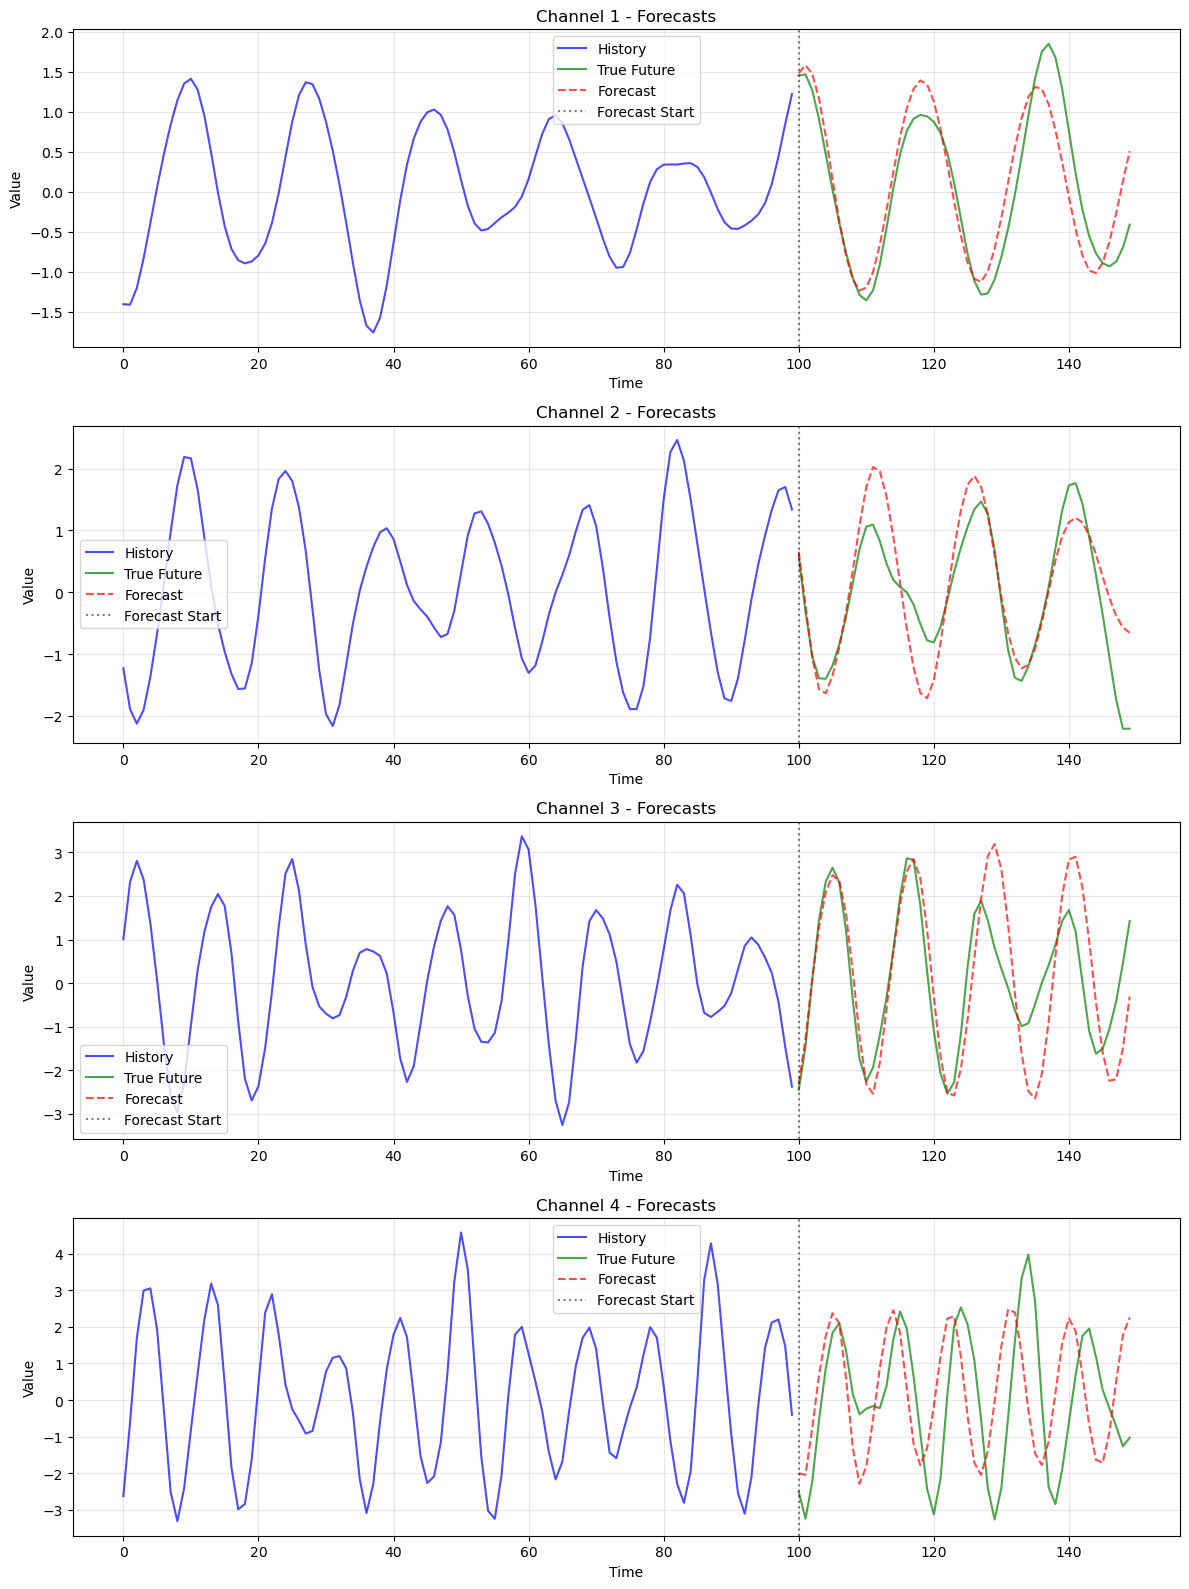

In [16]:
# Test VARMA implementation with multi-channel data
Y_concat_multi = np.concatenate(Y_multi, axis=0)
Z_concat_multi = Y_concat_multi.copy()
print(
    f"Multi-channel training data shape - Y: {Y_concat_multi.shape}, Z: {Z_concat_multi.shape}"
)

# Fit VARMA using VARMA method
print(f"\nFitting VARMA(p={p_super}, q={q_super}) on multi-channel data...")
(
    beta_ols_multi,
    resid_proxy_multi,
    poles_multi,
    channel_means_multi,
    channel_stds_multi,
    n_Y_multi,
    n_Z_multi,
) = fit_regularized_robust_varma(
    Y_concat_multi,
    Z=Z_concat_multi,
    p=p_super,
    q=q_super,
    long_ar_lags=long_ar_lags_super,
    target_pole_radius=target_pole_radius,
    apply_zscoring=True,
)

print(f"Beta shape: {beta_ols_multi.shape}")
print(f"n_channels_Y: {n_Y_multi}, n_channels_Z: {n_Z_multi}")
print(f"\nPole information:")
print(f"  Original max pole: {np.max(np.abs(poles_multi['original'])):.6f}")
print(f"  Regularized max pole: {np.max(np.abs(poles_multi['regularized'])):.6f}")

# Test forecast
Y_past_multi_super = Y_multi[0][:100]
Z_past_multi_super = Y_past_multi_super.copy()

# Apply per-channel z-scoring
Y_past_multi_zscored = np.zeros_like(Y_past_multi_super)
for ch_idx in range(n_Y_multi):
    mean_ch = channel_means_multi[ch_idx]
    std_ch = channel_stds_multi[ch_idx]
    Y_past_multi_zscored[:, ch_idx] = (Y_past_multi_super[:, ch_idx] - mean_ch) / std_ch

Z_past_multi_zscored = np.zeros_like(Z_past_multi_super)
for ch_idx in range(n_Z_multi):
    global_ch_idx = n_Y_multi + ch_idx
    mean_ch = channel_means_multi[global_ch_idx]
    std_ch = channel_stds_multi[global_ch_idx]
    Z_past_multi_zscored[:, ch_idx] = (Z_past_multi_super[:, ch_idx] - mean_ch) / std_ch

data_past_multi = np.concatenate([Y_past_multi_zscored, Z_past_multi_zscored], axis=1)
data_past_multi_df = pd.DataFrame(data_past_multi)

if len(data_past_multi) >= long_ar_lags_super:
    resid_past_multi = calc_long_AR_residuals(data_past_multi_df, long_ar_lags_super)
    history_resid_multi_super = (
        resid_past_multi.values[-q_super:]
        if len(resid_past_multi) >= q_super
        else np.zeros((q_super, data_past_multi.shape[1]))
    )
else:
    history_resid_multi_super = np.zeros((q_super, data_past_multi.shape[1]))

# Forecast in z-scored space
Yf_multi_zscored = forecast_varma_ols(
    beta_ols_multi,
    history_data=data_past_multi[-p_super:],
    history_resid=history_resid_multi_super,
    n_steps=50,
    p=p_super,
    q=q_super,
)

# Un-scale forecasts
Yf_multi_super = np.zeros_like(Yf_multi_zscored[:, :n_Y_multi])
for ch_idx in range(n_Y_multi):
    mean_ch = channel_means_multi[ch_idx]
    std_ch = channel_stds_multi[ch_idx]
    Yf_multi_super[:, ch_idx] = Yf_multi_zscored[:, ch_idx] * std_ch + mean_ch

print(f"\nMulti-channel forecast shape: {Yf_multi_super.shape}")
print(f"Forecast std per channel: {Yf_multi_super.std(axis=0)}")
plot_forecasts(
    Y_multi, Yf_multi_super, Y_past_multi_super, trial_idx=0, history_len=100
)

## 9. Ridge Regression for VARMA Fitting

Ridge regression can help with:
- **Overfitting**: When using many lags (high p, q), OLS can overfit
- **Numerical stability**: Lagged features can be highly correlated
- **Variable amplitude data**: Regularization smooths coefficient estimates

LetVARMA compare OLS vs Ridge regression.


In [17]:
from sklearn.linear_model import Ridge


def fit_regularized_robust_varma_ridge(
    Y: np.ndarray,
    Z: Optional[np.ndarray] = None,
    p: int = 20,
    q: int = 1,
    long_ar_lags: int = 20,
    target_pole_radius: float = 0.999,
    apply_zscoring: bool = True,
    alpha: float = 1.0,  # Ridge regularization strength
) -> tuple[np.ndarray, np.ndarray, dict[str, np.ndarray], dict, dict, int, int]:
    """
    Ridge-regularized version of fit_regularized_robust_varma.

    Parameters:
    -----------
    alpha : float
        Ridge regularization strength. Larger values = more regularization.
        Common values: 0.1, 1.0, 10.0, 100.0
    """
    # Same setup as before
    if Z is None:
        Z = Y.copy()

    # Per-channel z-scoring
    channel_means = {}
    channel_stds = {}
    n_channels_Y = Y.shape[1]
    n_channels_Z = Z.shape[1]

    Y_concat = np.concatenate([Y], axis=0) if isinstance(Y, list) else Y
    Z_concat = np.concatenate([Z], axis=0) if isinstance(Z, list) else Z

    if apply_zscoring:
        Y_zscored = np.zeros_like(Y_concat)
        for ch_idx in range(n_channels_Y):
            mean_ch = Y_concat[:, ch_idx].mean()
            std_ch = Y_concat[:, ch_idx].std()
            if std_ch > 1e-10:
                Y_zscored[:, ch_idx] = (Y_concat[:, ch_idx] - mean_ch) / std_ch
            else:
                Y_zscored[:, ch_idx] = Y_concat[:, ch_idx] - mean_ch
            channel_means[ch_idx] = mean_ch
            channel_stds[ch_idx] = std_ch

        Z_zscored = np.zeros_like(Z_concat)
        for ch_idx in range(n_channels_Z):
            global_ch_idx = n_channels_Y + ch_idx
            mean_ch = Z_concat[:, ch_idx].mean()
            std_ch = Z_concat[:, ch_idx].std()
            if std_ch > 1e-10:
                Z_zscored[:, ch_idx] = (Z_concat[:, ch_idx] - mean_ch) / std_ch
            else:
                Z_zscored[:, ch_idx] = Z_concat[:, ch_idx] - mean_ch
            channel_means[global_ch_idx] = mean_ch
            channel_stds[global_ch_idx] = std_ch
    else:
        Y_zscored = Y_concat
        Z_zscored = Z_concat

    data = np.concatenate([Y_zscored, Z_zscored], axis=1)
    df = pd.DataFrame(data)
    k = df.shape[1]

    # Step 1 & 2: Hannan-Rissanen Setup
    resid_proxy = calc_long_AR_residuals(df, long_ar_lags)
    effective_data = df.iloc[long_ar_lags:]
    Y_target = effective_data.iloc[max(p, q) :]
    X_list = []

    for i in range(1, p + 1):
        X_list.append(effective_data.shift(i).iloc[max(p, q) :].values)
    for i in range(1, q + 1):
        X_list.append(resid_proxy.shift(i).iloc[max(p, q) :].values)

    X_matrix = np.concatenate(X_list, axis=1)
    X_matrix = sm.add_constant(X_matrix)

    # Step 3: Solve via Ridge Regression (instead of OLS)
    # Fit Ridge for each output channel separately
    beta_ridge = np.zeros((X_matrix.shape[1], k))

    for ch_idx in range(k):
        ridge = Ridge(
            alpha=alpha, fit_intercept=False
        )  # fit_intercept=False because we have constant
        ridge.fit(X_matrix, Y_target.iloc[:, ch_idx])
        beta_ridge[:, ch_idx] = ridge.coef_

    poles = {}
    # Step 4: Pole Constraining (same as before)
    if p > 0:
        companion = build_companion_matrix(beta_ridge, p, k)
        eigenvalues = np.linalg.eigvals(companion)
        poles["original"] = eigenvalues
        max_pole = np.max(np.abs(eigenvalues))

        if max_pole > 0:
            gamma = target_pole_radius / max_pole
            for i in range(p):
                lag = i + 1
                beta_ridge[1 + i * k : 1 + (i + 1) * k, :] *= gamma**lag

        eigenvalues_reg = np.linalg.eigvals(build_companion_matrix(beta_ridge, p, k))
        poles["regularized"] = eigenvalues_reg

    return (
        beta_ridge,
        resid_proxy,
        poles,
        channel_means,
        channel_stds,
        n_channels_Y,
        n_channels_Z,
    )

### Compare OLS vs Ridge Regression

In [18]:
# Test with single channel data
print("Testing OLS vs Ridge Regression on single-channel data...")
print("=" * 60)

# OLS (original)
print("\n1. OLS (Original):")
beta_ols_test, resid_ols, poles_ols, means_ols, stds_ols, n_Y_ols, n_Z_ols = (
    fit_regularized_robust_varma(
        Y_concat_single,
        Z=Z_concat_single,
        p=p_super,
        q=q_super,
        long_ar_lags=long_ar_lags_super,
        target_pole_radius=target_pole_radius,
        apply_zscoring=True,
    )
)

# Ridge with different alpha values
alphas = [0.1, 1.0, 10.0, 100.0]
ridge_results = {}

for alpha in alphas:
    print(f"\n2. Ridge (alpha={alpha}):")
    (
        beta_ridge,
        resid_ridge,
        poles_ridge,
        means_ridge,
        stds_ridge,
        n_Y_ridge,
        n_Z_ridge,
    ) = fit_regularized_robust_varma_ridge(
        Y_concat_single,
        Z=Z_concat_single,
        p=p_super,
        q=q_super,
        long_ar_lags=long_ar_lags_super,
        target_pole_radius=target_pole_radius,
        apply_zscoring=True,
        alpha=alpha,
    )
    ridge_results[alpha] = {
        "beta": beta_ridge,
        "resid": resid_ridge,
        "poles": poles_ridge,
        "means": means_ridge,
        "stds": stds_ridge,
        "n_Y": n_Y_ridge,
        "n_Z": n_Z_ridge,
    }

    print(f"   Original max pole: {np.max(np.abs(poles_ridge['original'])):.6f}")
    print(f"   Regularized max pole: {np.max(np.abs(poles_ridge['regularized'])):.6f}")
    print(
        f"   Beta coefficient range: [{beta_ridge.min():.4f}, {beta_ridge.max():.4f}]"
    )
    print(f"   Beta coefficient std: {beta_ridge.std():.4f}")

print(
    f"\nOLS Beta coefficient range: [{beta_ols_test.min():.4f}, {beta_ols_test.max():.4f}]"
)
print(f"OLS Beta coefficient std: {beta_ols_test.std():.4f}")

Testing OLS vs Ridge Regression on single-channel data...

1. OLS (Original):

2. Ridge (alpha=0.1):
   Original max pole: 0.977866
   Regularized max pole: 0.999000
   Beta coefficient range: [-0.8329, 1.1497]
   Beta coefficient std: 0.5759

2. Ridge (alpha=1.0):
   Original max pole: 0.976924
   Regularized max pole: 0.999000
   Beta coefficient range: [-0.3672, 0.8741]
   Beta coefficient std: 0.3725

2. Ridge (alpha=10.0):
   Original max pole: 0.976049
   Regularized max pole: 0.999000
   Beta coefficient range: [-0.1561, 0.5957]
   Beta coefficient std: 0.2364

2. Ridge (alpha=100.0):
   Original max pole: 0.968859
   Regularized max pole: 0.999000
   Beta coefficient range: [-0.1335, 0.4188]
   Beta coefficient std: 0.1781

OLS Beta coefficient range: [-0.9491, 1.2176]
OLS Beta coefficient std: 0.6308


In [19]:
# Compare predictions: OLS vs Ridge
Y_test = Y_single[0]
Z_test = Y_test.copy()

# Apply z-scoring for OLS
Y_test_zscored_ols = np.zeros_like(Y_test)
for ch_idx in range(n_Y_ols):
    mean_ch = means_ols[ch_idx]
    std_ch = stds_ols[ch_idx]
    Y_test_zscored_ols[:, ch_idx] = (Y_test[:, ch_idx] - mean_ch) / std_ch

Z_test_zscored_ols = np.zeros_like(Z_test)
for ch_idx in range(n_Z_ols):
    global_ch_idx = n_Y_ols + ch_idx
    mean_ch = means_ols[global_ch_idx]
    std_ch = stds_ols[global_ch_idx]
    Z_test_zscored_ols[:, ch_idx] = (Z_test[:, ch_idx] - mean_ch) / std_ch

data_test_ols = np.concatenate([Y_test_zscored_ols, Z_test_zscored_ols], axis=1)
data_test_ols_df = pd.DataFrame(data_test_ols)
resid_test_ols = calc_long_AR_residuals(data_test_ols_df, long_ar_lags_super)

# OLS predictions
Yp_ols_zscored = predict_varma_ols(
    beta_ols_test, data_test_ols, resid_test_ols, p_super, q_super, long_ar_lags_super
)
Yp_ols = np.zeros_like(Yp_ols_zscored[:, :n_Y_ols])
for ch_idx in range(n_Y_ols):
    mean_ch = means_ols[ch_idx]
    std_ch = stds_ols[ch_idx]
    Yp_ols[:, ch_idx] = Yp_ols_zscored[:, ch_idx] * std_ch + mean_ch

# Ridge predictions for each alpha
Yp_ridge_dict = {}
for alpha in alphas:
    res = ridge_results[alpha]
    Y_test_zscored = np.zeros_like(Y_test)
    for ch_idx in range(res["n_Y"]):
        mean_ch = res["means"][ch_idx]
        std_ch = res["stds"][ch_idx]
        Y_test_zscored[:, ch_idx] = (Y_test[:, ch_idx] - mean_ch) / std_ch

    Z_test_zscored = np.zeros_like(Z_test)
    for ch_idx in range(res["n_Z"]):
        global_ch_idx = res["n_Y"] + ch_idx
        mean_ch = res["means"][global_ch_idx]
        std_ch = res["stds"][global_ch_idx]
        Z_test_zscored[:, ch_idx] = (Z_test[:, ch_idx] - mean_ch) / std_ch

    data_test = np.concatenate([Y_test_zscored, Z_test_zscored], axis=1)
    data_test_df = pd.DataFrame(data_test)
    resid_test = calc_long_AR_residuals(data_test_df, long_ar_lags_super)

    Yp_ridge_zscored = predict_varma_ols(
        res["beta"], data_test, resid_test, p_super, q_super, long_ar_lags_super
    )
    Yp_ridge = np.zeros_like(Yp_ridge_zscored[:, : res["n_Y"]])
    for ch_idx in range(res["n_Y"]):
        mean_ch = res["means"][ch_idx]
        std_ch = res["stds"][ch_idx]
        Yp_ridge[:, ch_idx] = Yp_ridge_zscored[:, ch_idx] * std_ch + mean_ch

    Yp_ridge_dict[alpha] = Yp_ridge

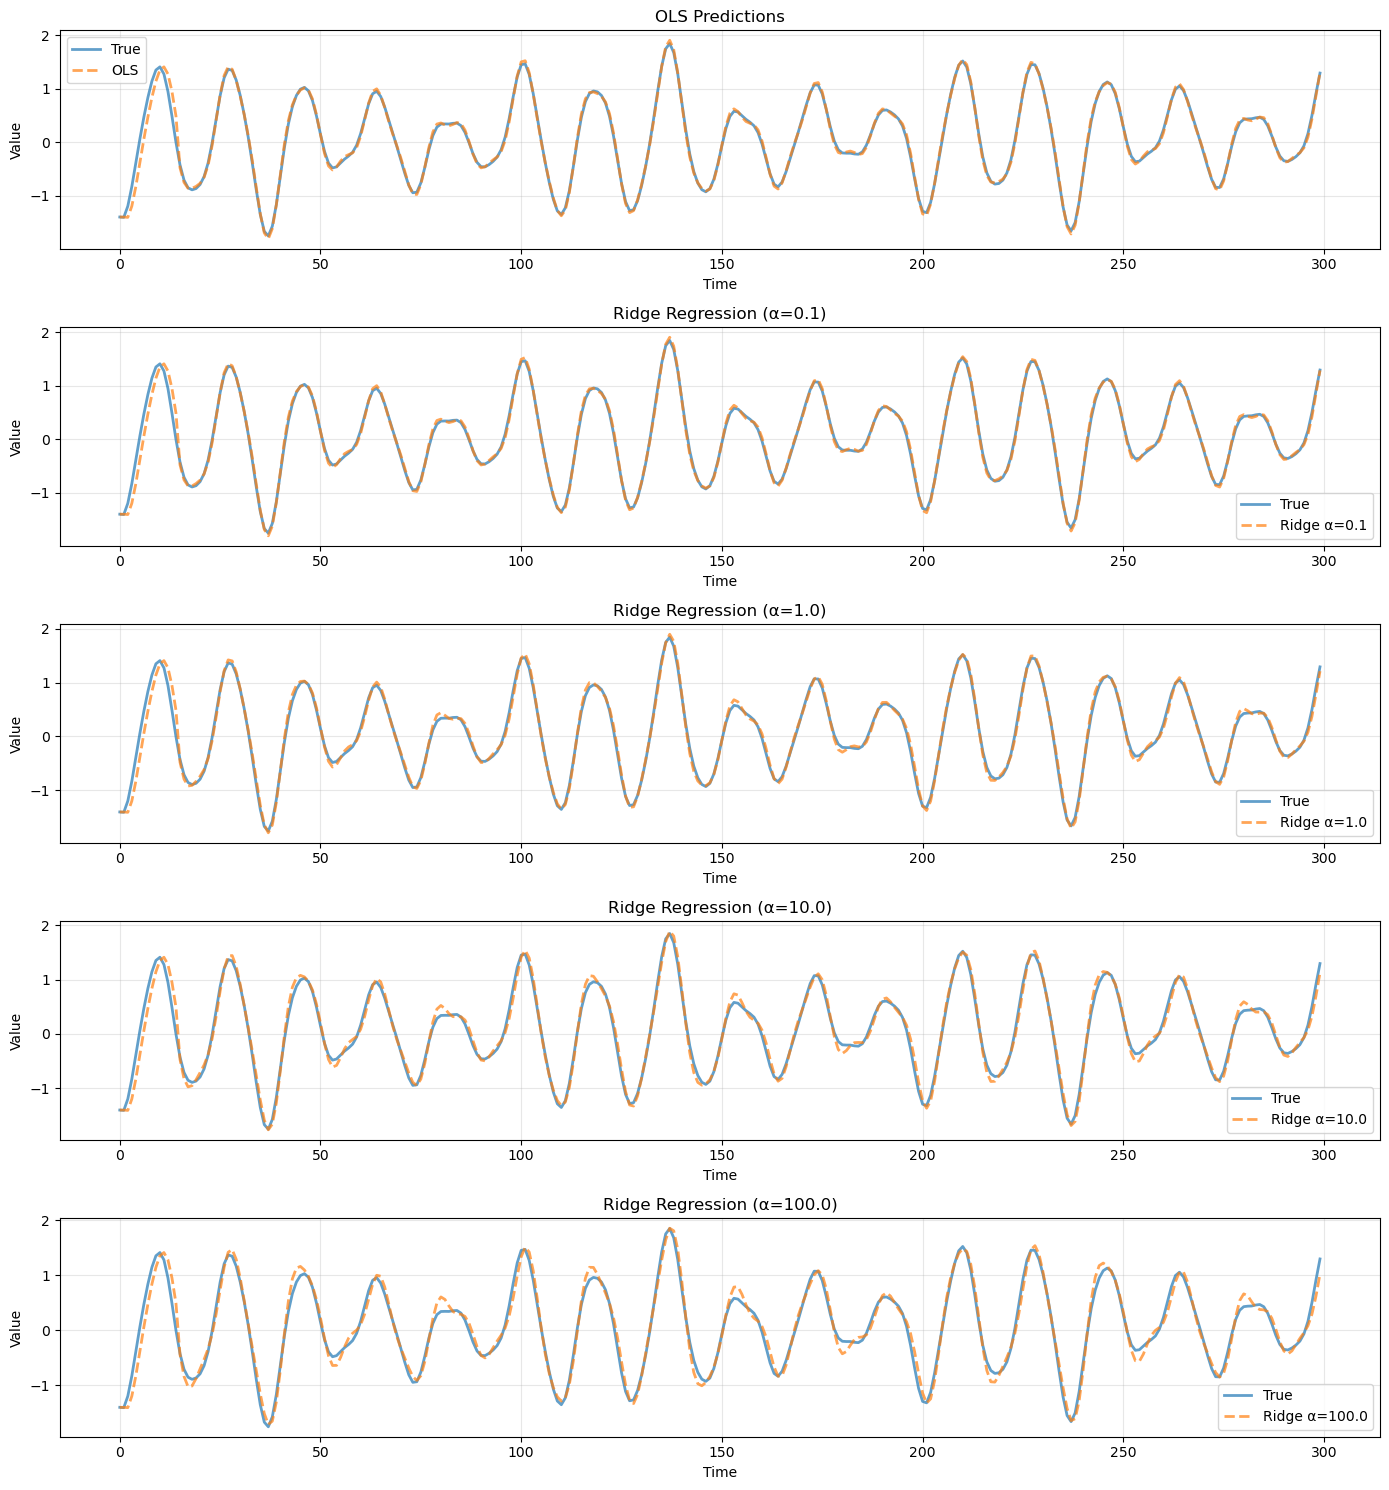

In [20]:
# Visualize predictions: OLS vs Ridge
fig, axes = plt.subplots(len(alphas) + 1, 1, figsize=(14, 3 * (len(alphas) + 1)))

# OLS
ax = axes[0]
y_true = Y_test[:300, 0]
y_pred_ols = Yp_ols[:300, 0]
ax.plot(y_true, label="True", alpha=0.7, linewidth=2)
ax.plot(y_pred_ols, label=f"OLS", alpha=0.7, linewidth=2, linestyle="--")
ax.set_title("OLS Predictions")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)

# Ridge for each alpha
for idx, alpha in enumerate(alphas, 1):
    ax = axes[idx]
    y_pred_ridge = Yp_ridge_dict[alpha][:300, 0]
    ax.plot(y_true, label="True", alpha=0.7, linewidth=2)
    ax.plot(
        y_pred_ridge, label=f"Ridge α={alpha}", alpha=0.7, linewidth=2, linestyle="--"
    )
    ax.set_title(f"Ridge Regression (α={alpha})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Compare OLS vs Ridge Forecasts

In [21]:
# Compare OLS vs Ridge forecasts for multi-channel data
print("Testing OLS vs Ridge Regression forecasts on multi-channel data...")
print("=" * 60)

# Use the same multi-channel data that was used earlier
# OLS forecast (already computed above as Yf_multi_super)
print("\n1. OLS Forecast:")
print(f"  Forecast shape: {Yf_multi_super.shape}")
print(f"  Forecast std per channel: {Yf_multi_super.std(axis=0)}")

# Ridge forecasts for different alpha values
alphas_multi = [0.1, 1.0, 10.0, 100.0]
Yf_ridge_multi_dict = {}

for alpha in alphas_multi:
    print(f"\n2. Ridge Forecast (alpha={alpha}):")

    # Fit Ridge model
    (
        beta_ridge_multi,
        resid_ridge_multi,
        poles_ridge_multi,
        means_ridge_multi,
        stds_ridge_multi,
        n_Y_ridge_multi,
        n_Z_ridge_multi,
    ) = fit_regularized_robust_varma_ridge(
        Y_concat_multi,
        Z=Z_concat_multi,
        p=p_super,
        q=q_super,
        long_ar_lags=long_ar_lags_super,
        target_pole_radius=target_pole_radius,
        apply_zscoring=True,
        alpha=alpha,
    )

    # Prepare history data for forecasting (same as OLS)
    Y_past_ridge = Y_multi[0][:100]
    Z_past_ridge = Y_past_ridge.copy()

    # Apply per-channel z-scoring
    Y_past_ridge_zscored = np.zeros_like(Y_past_ridge)
    for ch_idx in range(n_Y_ridge_multi):
        mean_ch = means_ridge_multi[ch_idx]
        std_ch = stds_ridge_multi[ch_idx]
        Y_past_ridge_zscored[:, ch_idx] = (Y_past_ridge[:, ch_idx] - mean_ch) / std_ch

    Z_past_ridge_zscored = np.zeros_like(Z_past_ridge)
    for ch_idx in range(n_Z_ridge_multi):
        global_ch_idx = n_Y_ridge_multi + ch_idx
        mean_ch = means_ridge_multi[global_ch_idx]
        std_ch = stds_ridge_multi[global_ch_idx]
        Z_past_ridge_zscored[:, ch_idx] = (Z_past_ridge[:, ch_idx] - mean_ch) / std_ch

    data_past_ridge = np.concatenate(
        [Y_past_ridge_zscored, Z_past_ridge_zscored], axis=1
    )
    data_past_ridge_df = pd.DataFrame(data_past_ridge)

    # Compute residuals for history
    if len(data_past_ridge) >= long_ar_lags_super:
        resid_past_ridge = calc_long_AR_residuals(
            data_past_ridge_df, long_ar_lags_super
        )
        history_resid_ridge = (
            resid_past_ridge.values[-q_super:]
            if len(resid_past_ridge) >= q_super
            else np.zeros((q_super, data_past_ridge.shape[1]))
        )
    else:
        history_resid_ridge = np.zeros((q_super, data_past_ridge.shape[1]))

    # Forecast in z-scored space
    Yf_ridge_zscored = forecast_varma_ols(
        beta_ridge_multi,
        history_data=data_past_ridge[-p_super:],
        history_resid=history_resid_ridge,
        n_steps=50,
        p=p_super,
        q=q_super,
    )

    # Un-scale forecasts
    Yf_ridge_multi = np.zeros_like(Yf_ridge_zscored[:, :n_Y_ridge_multi])
    for ch_idx in range(n_Y_ridge_multi):
        mean_ch = means_ridge_multi[ch_idx]
        std_ch = stds_ridge_multi[ch_idx]
        Yf_ridge_multi[:, ch_idx] = Yf_ridge_zscored[:, ch_idx] * std_ch + mean_ch

    Yf_ridge_multi_dict[alpha] = Yf_ridge_multi

    print(f"  Forecast shape: {Yf_ridge_multi.shape}")
    print(f"  Forecast std per channel: {Yf_ridge_multi.std(axis=0)}")
    print(f"  Original max pole: {np.max(np.abs(poles_ridge_multi['original'])):.6f}")
    print(
        f"  Regularized max pole: {np.max(np.abs(poles_ridge_multi['regularized'])):.6f}"
    )

Testing OLS vs Ridge Regression forecasts on multi-channel data...

1. OLS Forecast:
  Forecast shape: (50, 4)
  Forecast std per channel: [0.90393235 1.10466215 1.91578591 1.56979402]

2. Ridge Forecast (alpha=0.1):
  Forecast shape: (50, 4)
  Forecast std per channel: [0.90208391 1.14549192 1.7152609  1.67670263]
  Original max pole: 0.983003
  Regularized max pole: 0.999000

2. Ridge Forecast (alpha=1.0):
  Forecast shape: (50, 4)
  Forecast std per channel: [0.83056047 1.12350407 1.76943325 1.67208678]
  Original max pole: 0.980492
  Regularized max pole: 0.999000

2. Ridge Forecast (alpha=10.0):
  Forecast shape: (50, 4)
  Forecast std per channel: [0.77768943 0.92781134 1.73098033 1.49930715]
  Original max pole: 0.978177
  Regularized max pole: 0.999000

2. Ridge Forecast (alpha=100.0):
  Forecast shape: (50, 4)
  Forecast std per channel: [0.74468392 0.95518035 1.66208185 1.43169803]
  Original max pole: 0.973033
  Regularized max pole: 0.999000


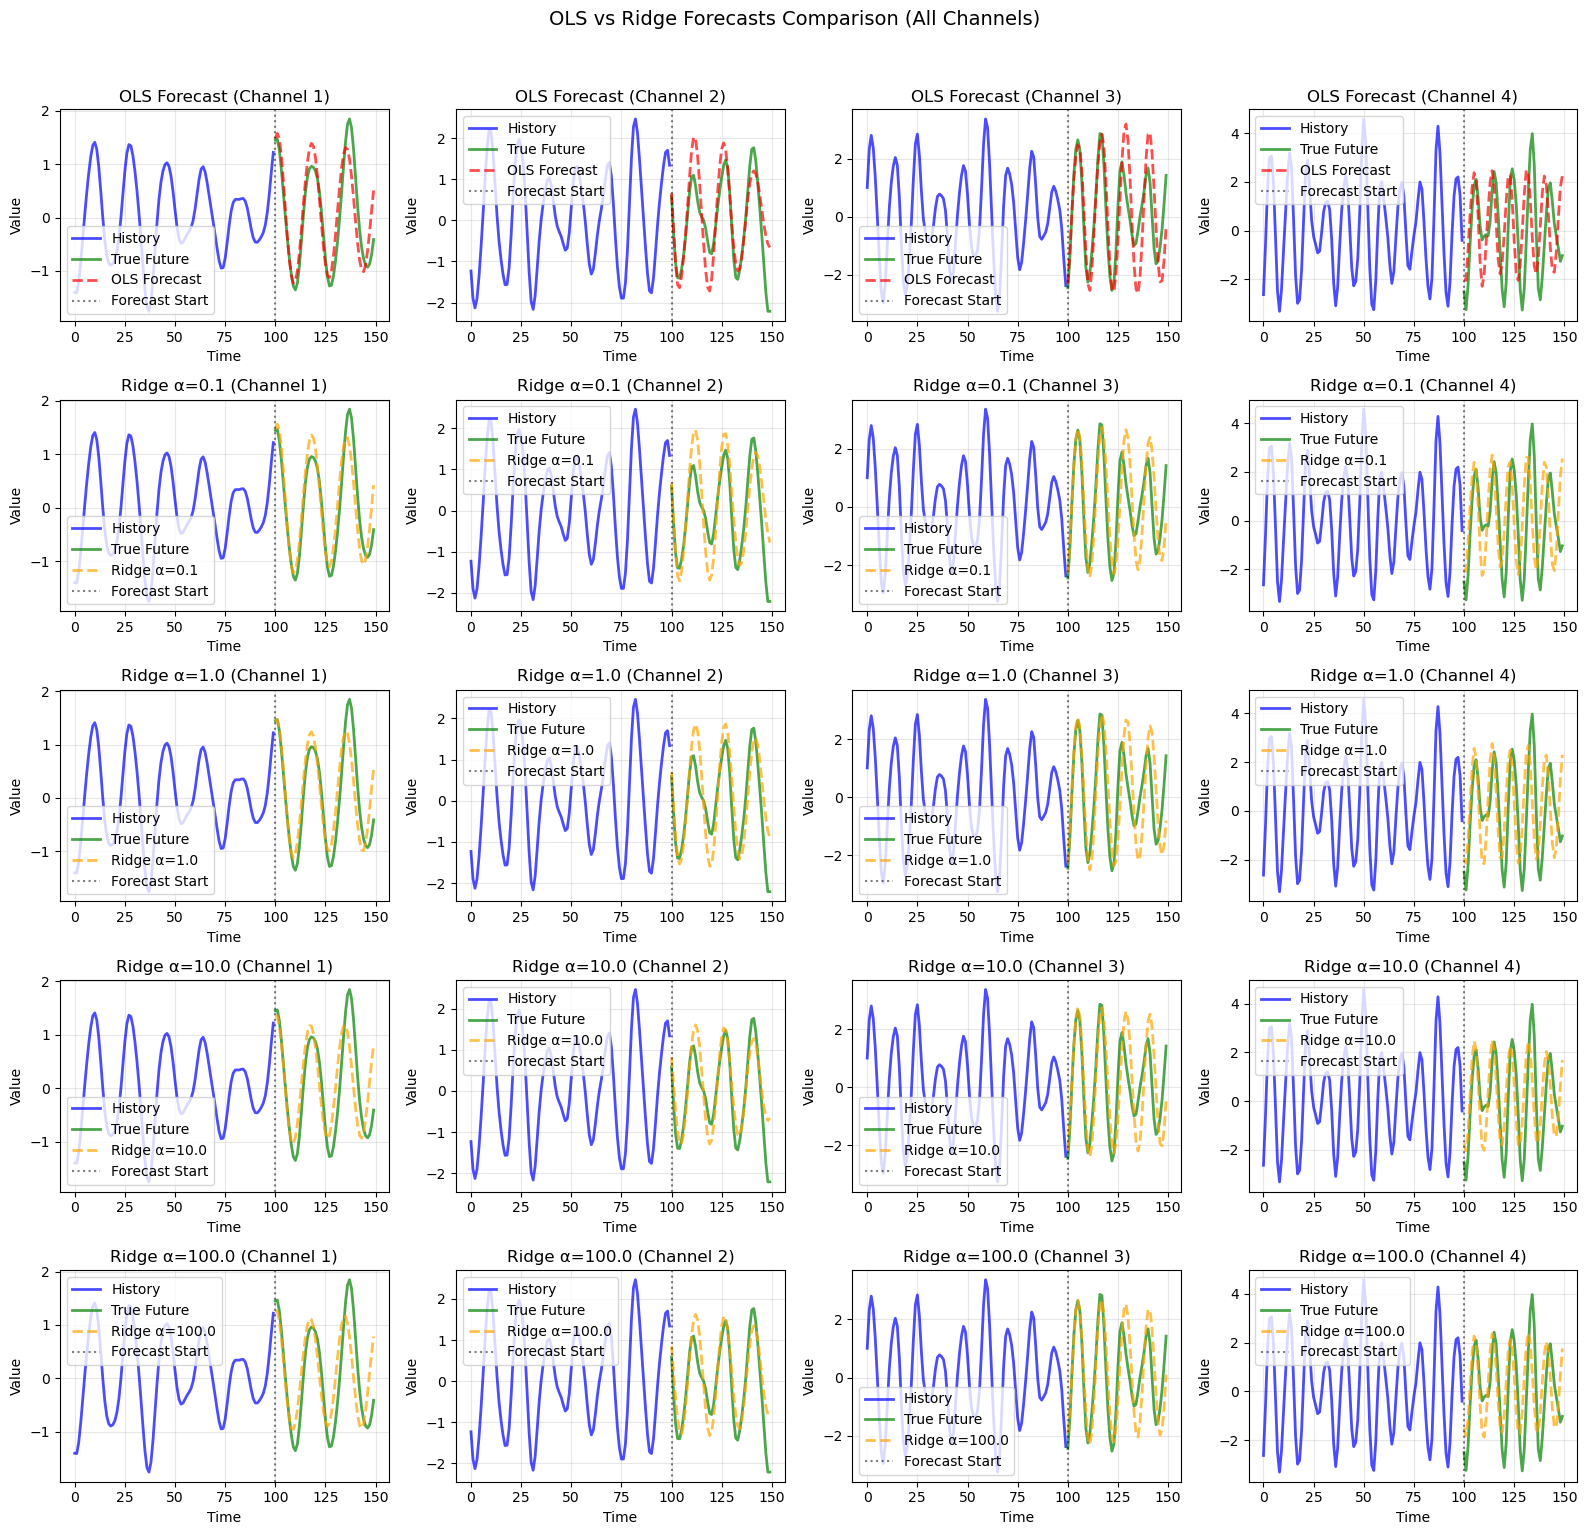


Forecast Comparison (Multi-Channel, Per Channel):

OLS Forecasts:
  Channel 1: std=0.9039, range=[-1.2305, 1.5767]
  Channel 2: std=1.1047, range=[-1.7164, 2.0270]
  Channel 3: std=1.9158, range=[-2.6430, 3.1889]
  Channel 4: std=1.5698, range=[-2.2876, 2.4746]

Ridge (α=0.1) Forecasts:
  Channel 1: std=0.9021, range=[-1.2202, 1.5654]
  Channel 2: std=1.1455, range=[-1.7105, 1.9542]
  Channel 3: std=1.7153, range=[-2.4229, 2.7445]
  Channel 4: std=1.6767, range=[-2.2487, 2.6978]

Ridge (α=1.0) Forecasts:
  Channel 1: std=0.8306, range=[-1.1211, 1.4694]
  Channel 2: std=1.1235, range=[-1.5950, 1.8651]
  Channel 3: std=1.7694, range=[-2.5044, 2.8507]
  Channel 4: std=1.6721, range=[-2.1675, 2.7639]

Ridge (α=10.0) Forecasts:
  Channel 1: std=0.7777, range=[-1.0397, 1.3549]
  Channel 2: std=0.9278, range=[-1.2924, 1.6058]
  Channel 3: std=1.7310, range=[-2.4022, 2.7489]
  Channel 4: std=1.4993, range=[-2.0355, 2.5075]

Ridge (α=100.0) Forecasts:
  Channel 1: std=0.7447, range=[-0.9571, 1

In [22]:
# Visualize OLS vs Ridge forecasts for multi-channel data (all channels)
n_channels = Y_multi[0].shape[1]
n_methods = len(alphas_multi) + 1  # OLS + Ridge for each alpha

# Create subplots: one row per method, one column per channel
fig, axes = plt.subplots(n_methods, n_channels, figsize=(4 * n_channels, 3 * n_methods))

if n_methods == 1:
    axes = axes.reshape(1, -1)
if n_channels == 1:
    axes = axes.reshape(-1, 1)

# OLS forecast (row 0)
row_idx = 0
for ch_idx in range(n_channels):
    ax = axes[row_idx, ch_idx]
    history = Y_past_multi_super[:100, ch_idx]
    t_history = np.arange(len(history))
    ax.plot(t_history, history, "b-", label="History", alpha=0.7, linewidth=2)

    true_future = Y_multi[0][100:150, ch_idx]
    t_future = np.arange(100, 100 + len(true_future))
    ax.plot(t_future, true_future, "g-", label="True Future", alpha=0.7, linewidth=2)

    forecast_ols = Yf_multi_super[:, ch_idx]
    ax.plot(t_future, forecast_ols, "r--", label="OLS Forecast", alpha=0.7, linewidth=2)

    ax.axvline(x=100, color="k", linestyle=":", alpha=0.5, label="Forecast Start")
    ax.set_title(f"OLS Forecast (Channel {ch_idx+1})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Ridge forecasts for each alpha
for alpha_idx, alpha in enumerate(alphas_multi, 1):
    row_idx = alpha_idx
    for ch_idx in range(n_channels):
        ax = axes[row_idx, ch_idx]
        history = Y_past_multi_super[:100, ch_idx]
        t_history = np.arange(len(history))
        ax.plot(t_history, history, "b-", label="History", alpha=0.7, linewidth=2)

        true_future = Y_multi[0][100:150, ch_idx]
        t_future = np.arange(100, 100 + len(true_future))
        ax.plot(
            t_future, true_future, "g-", label="True Future", alpha=0.7, linewidth=2
        )

        forecast_ridge = Yf_ridge_multi_dict[alpha][:, ch_idx]
        ax.plot(
            t_future,
            forecast_ridge,
            "orange",
            linestyle="--",
            label=f"Ridge α={alpha}",
            alpha=0.7,
            linewidth=2,
        )

        ax.axvline(x=100, color="k", linestyle=":", alpha=0.5, label="Forecast Start")
        ax.set_title(f"Ridge α={alpha} (Channel {ch_idx+1})")
        ax.set_xlabel("Time")
        ax.set_ylabel("Value")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle("OLS vs Ridge Forecasts Comparison (All Channels)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Compare forecast statistics per channel
print("\nForecast Comparison (Multi-Channel, Per Channel):")
print(f"\nOLS Forecasts:")
for ch_idx in range(n_channels):
    ch_data = Yf_multi_super[:, ch_idx]
    print(
        f"  Channel {ch_idx+1}: std={ch_data.std():.4f}, range=[{ch_data.min():.4f}, {ch_data.max():.4f}]"
    )

for alpha in alphas_multi:
    Yf_ridge = Yf_ridge_multi_dict[alpha]
    print(f"\nRidge (α={alpha}) Forecasts:")
    for ch_idx in range(n_channels):
        ch_data = Yf_ridge[:, ch_idx]
        print(
            f"  Channel {ch_idx+1}: std={ch_data.std():.4f}, range=[{ch_data.min():.4f}, {ch_data.max():.4f}]"
        )

# Overall statistics
print("\nOverall Forecast Statistics:")
print(
    f"  OLS - Forecast std: {Yf_multi_super.std():.4f}, range: [{Yf_multi_super.min():.4f}, {Yf_multi_super.max():.4f}]"
)
for alpha in alphas_multi:
    Yf_ridge = Yf_ridge_multi_dict[alpha]
    print(
        f"  Ridge (α={alpha}) - Forecast std: {Yf_ridge.std():.4f}, range: [{Yf_ridge.min():.4f}, {Yf_ridge.max():.4f}]"
    )

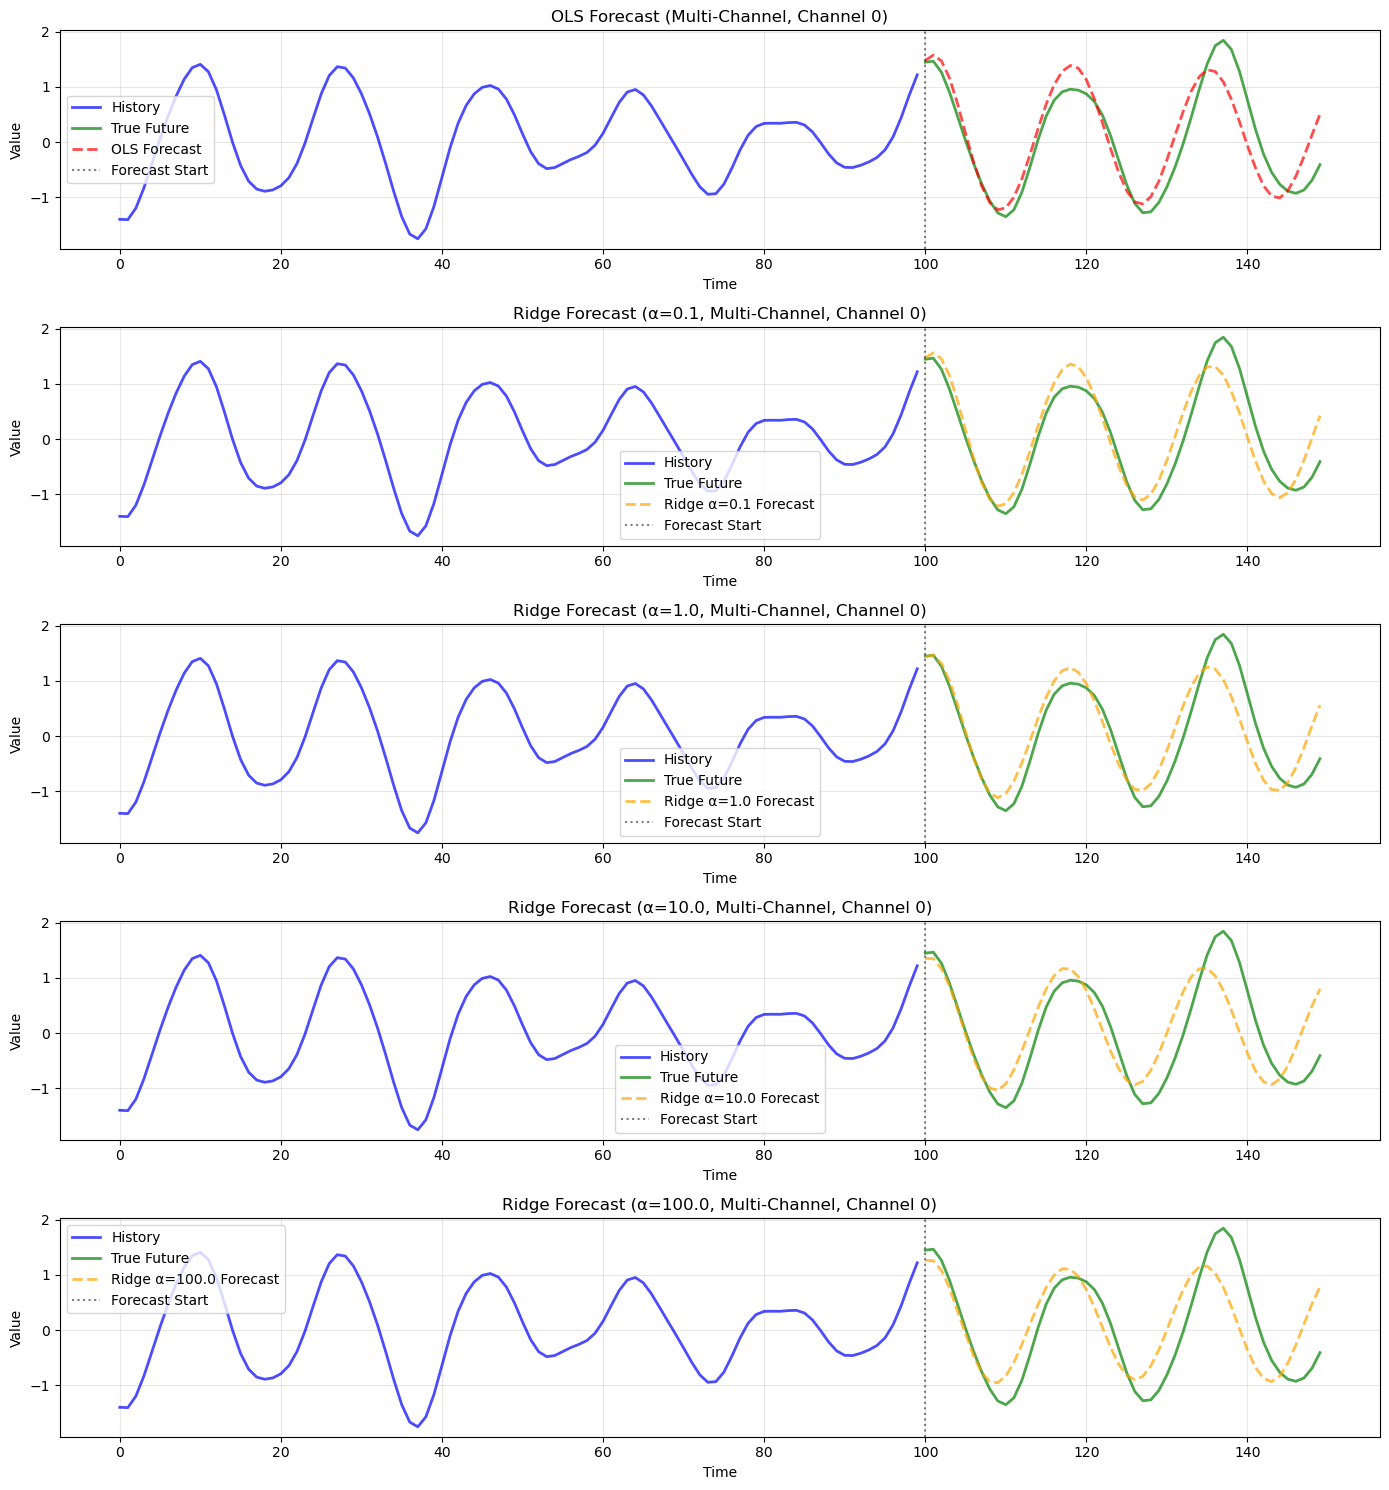


Forecast Comparison (Multi-Channel):
  OLS - Forecast std: 1.4300, range: [-2.6430, 3.1889]
  Ridge (α=0.1) - Forecast std: 1.4040, range: [-2.4229, 2.7445]
  Ridge (α=1.0) - Forecast std: 1.4038, range: [-2.5044, 2.8507]
  Ridge (α=10.0) - Forecast std: 1.2955, range: [-2.4022, 2.7489]
  Ridge (α=100.0) - Forecast std: 1.2533, range: [-2.3126, 2.6805]


In [23]:
# Visualize OLS vs Ridge forecasts for multi-channel data
fig, axes = plt.subplots(
    len(alphas_multi) + 1, 1, figsize=(14, 3 * (len(alphas_multi) + 1))
)

# OLS forecast
ax = axes[0]
history = Y_past_multi_super[:100, 0]
t_history = np.arange(len(history))
ax.plot(t_history, history, "b-", label="History", alpha=0.7, linewidth=2)

true_future = Y_multi[0][100:150, 0]
t_future = np.arange(100, 100 + len(true_future))
ax.plot(t_future, true_future, "g-", label="True Future", alpha=0.7, linewidth=2)

forecast_ols = Yf_multi_super[:, 0]
ax.plot(t_future, forecast_ols, "r--", label="OLS Forecast", alpha=0.7, linewidth=2)

ax.axvline(x=100, color="k", linestyle=":", alpha=0.5, label="Forecast Start")
ax.set_title("OLS Forecast (Multi-Channel, Channel 0)")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)

# Ridge forecasts for each alpha
for idx, alpha in enumerate(alphas_multi, 1):
    ax = axes[idx]
    history = Y_past_multi_super[:100, 0]
    t_history = np.arange(len(history))
    ax.plot(t_history, history, "b-", label="History", alpha=0.7, linewidth=2)

    true_future = Y_multi[0][100:150, 0]
    t_future = np.arange(100, 100 + len(true_future))
    ax.plot(t_future, true_future, "g-", label="True Future", alpha=0.7, linewidth=2)

    forecast_ridge = Yf_ridge_multi_dict[alpha][:, 0]
    ax.plot(
        t_future,
        forecast_ridge,
        "orange",
        linestyle="--",
        label=f"Ridge α={alpha} Forecast",
        alpha=0.7,
        linewidth=2,
    )

    ax.axvline(x=100, color="k", linestyle=":", alpha=0.5, label="Forecast Start")
    ax.set_title(f"Ridge Forecast (α={alpha}, Multi-Channel, Channel 0)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare forecast statistics
print("\nForecast Comparison (Multi-Channel):")
print(
    f"  OLS - Forecast std: {Yf_multi_super.std():.4f}, range: [{Yf_multi_super.min():.4f}, {Yf_multi_super.max():.4f}]"
)
for alpha in alphas_multi:
    Yf_ridge = Yf_ridge_multi_dict[alpha]
    print(
        f"  Ridge (α={alpha}) - Forecast std: {Yf_ridge.std():.4f}, range: [{Yf_ridge.min():.4f}, {Yf_ridge.max():.4f}]"
    )